# Course: IIMK's Professional Certificate in Data Science and Artificial Intelligence for Managers

**Student Name:** Lalit Nayyar  
**Email ID:** lalitnayyar@gmail.com  
**Assignment Name:** Week 3: Required Assignment 3.1
**Final for submission**

---

In [1]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn kaggle folium --upgrade

  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aider-chat 0.75.1 requires numpy==1.26.4, but you have numpy 2.0.2 which is incompatible.
aider-chat 0.75.1 requires packaging==24.2, but you have packaging 23.2 which is incompatible.
langchain 0.3.19 requires numpy<2,>=1.26.4; python_version < "3.12", but you have numpy 2.0.2 which is incompatible.
langchain-community 0.3.18 requires numpy<2,>=1.26.4; python_version < "3.12", but you have numpy 2.0.2 which is incompatible.
transformers 4.48.3 requires tokenizers<0.22,>=0.21, but you have tokenizers 0.19.1 which is incompatible.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Safe plotting configuration that works everywhere
def setup_plotting():
    # Basic matplotlib settings
    plt.rcParams['figure.figsize'] = [10, 6]
    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    
    # Basic seaborn settings without using style files
    sns.set_context("notebook")
    
    # Set a simple color palette
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    sns.set_palette(colors)

# Apply the safe plotting configuration
setup_plotting()

### Download and Load the Dataset

In [2]:
# Download the dataset using Kaggle API
import os
from kaggle.api.kaggle_api_extended import KaggleApi

def download_dataset():
    try:
        api = KaggleApi()
        api.authenticate()
        
        print("Downloading California Housing Prices dataset...")
        api.dataset_download_files('camnugent/california-housing-prices', 
                                  path='.', 
                                  unzip=True)
        print("Dataset downloaded successfully!")
        
    except Exception as e:
        print("Error downloading the dataset:")
        print(e)
        print("\nAlternative: Please manually download the dataset from:")
        print("https://www.kaggle.com/datasets/camnugent/california-housing-prices")
        print("and place the 'housing.csv' file in the current directory.")

# Download the dataset if it doesn't exist
if not os.path.exists('housing.csv'):
    download_dataset()

In [3]:
# Load the dataset
df = pd.read_csv('housing.csv')

# Display basic information
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

First few rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Real Estate Agent Analysis

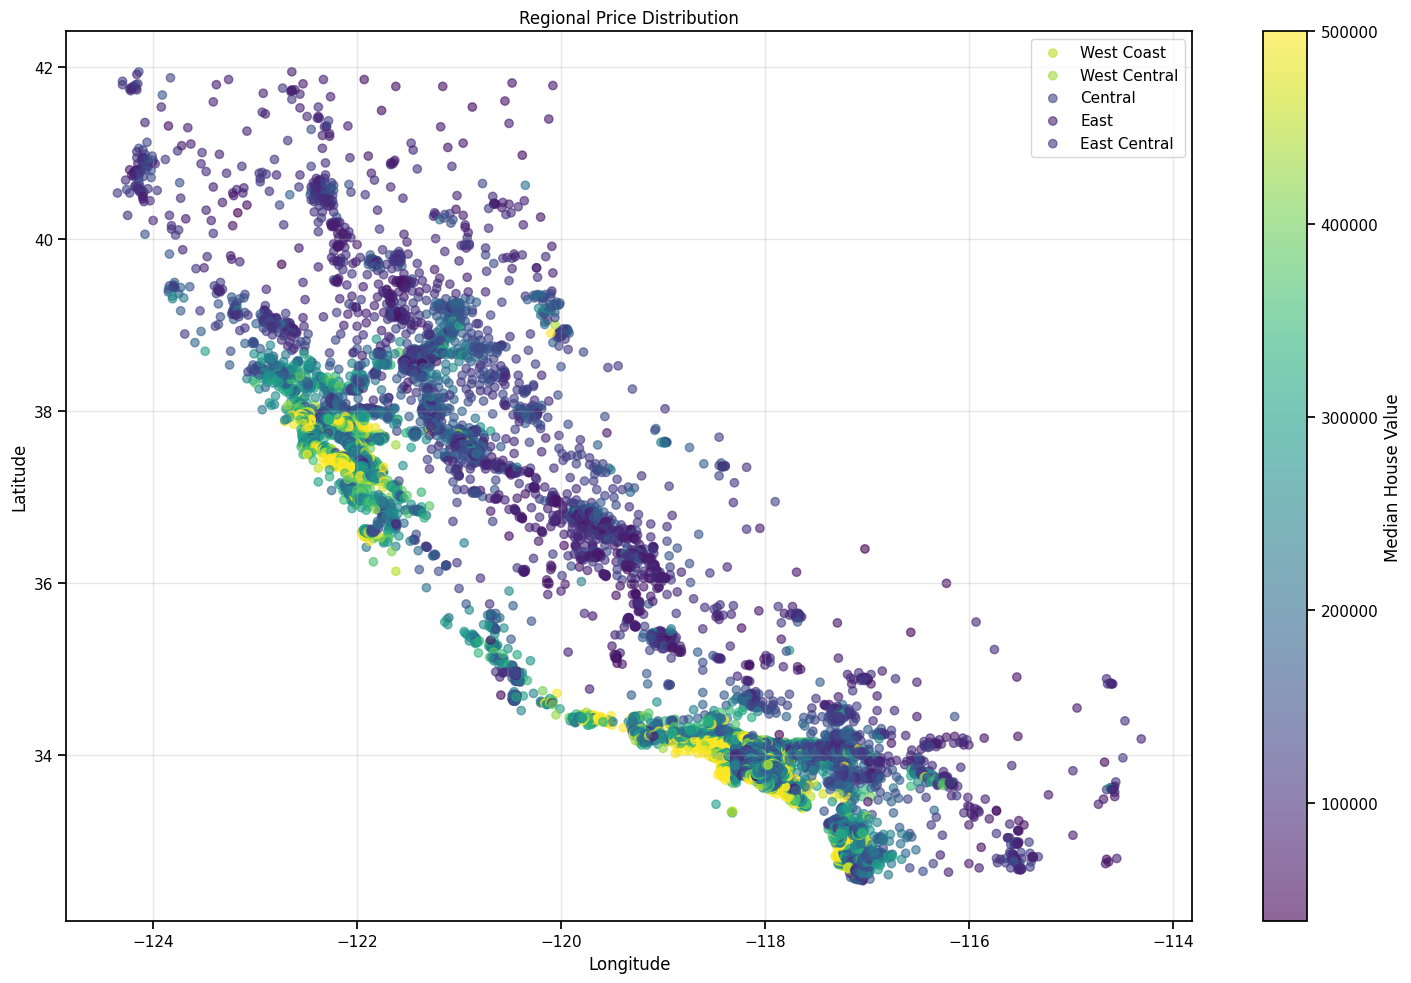


Regional Market Statistics:


median_house_value            median_income  \
                                               mean        std          mean   
longitude_region latitude_region                                               
West Coast       South                          NaN        NaN           NaN   
                 Central                  326156.42  104473.15          5.58   
                 North                    240223.04  126244.68          4.07   
West Central     South                          NaN        NaN           NaN   
                 Central                  212851.17  100833.49          3.87   
                 North                    144189.59   74997.43          3.43   
Central          South                    292744.56  125824.83          4.25   
                 Central                  212043.13  137319.27          3.91   
                 North                    132417.07   44162.94          3.10   
East Central     South                    197702.39   84608.79          3.66   
                 Central                  226046.03  100292.87          3.76   
                 North                    108300.00        NaN          2.12   
East             South                    199415.16  105008.25          4.10   
                 Central                  129698.03   68449.83          3.40   
                 North                          NaN        NaN           NaN   

                                 housing_median_age  
                                               mean  
longitude_region latitude_region                     
West Coast       South                          NaN  
                 Central                      29.08  
                 North                        33.65  
West Central     South                          NaN  
                 Central                      24.04  
                 North                        24.73  
Central          South                        35.58  
                 Central                      28.48  
                 North                        18.29  
East Central     South                        31.99  
                 Central                      34.71  
                 North                        16.00  
East             South                        21.36  
                 Central                      24.10  
                 North                          NaN

In [5]:
# 1. Region-specific Price Analysis

# Create geographical regions
df['longitude_region'] = pd.qcut(df['longitude'], q=5, labels=['West Coast', 'West Central', 'Central', 'East Central', 'East'])
df['latitude_region'] = pd.qcut(df['latitude'], q=3, labels=['South', 'Central', 'North'])

# Calculate regional statistics
regional_stats = df.groupby(['longitude_region', 'latitude_region']).agg({
    'median_house_value': ['mean', 'std'],
    'median_income': 'mean',
    'housing_median_age': 'mean'
}).round(2)

# Create figure and axis objects with a single subplot
fig, ax = plt.subplots(figsize=(15, 10))

# Plot data for each region
for region in df['longitude_region'].unique():
    region_data = df[df['longitude_region'] == region]
    scatter = ax.scatter(region_data['longitude'], 
                        region_data['latitude'], 
                        c=region_data['median_house_value'],
                        alpha=0.6,
                        label=region)

plt.colorbar(scatter, label='Median House Value')
ax.set_title('Regional Price Distribution')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

# Display regional statistics
print("\nRegional Market Statistics:")
display(regional_stats)

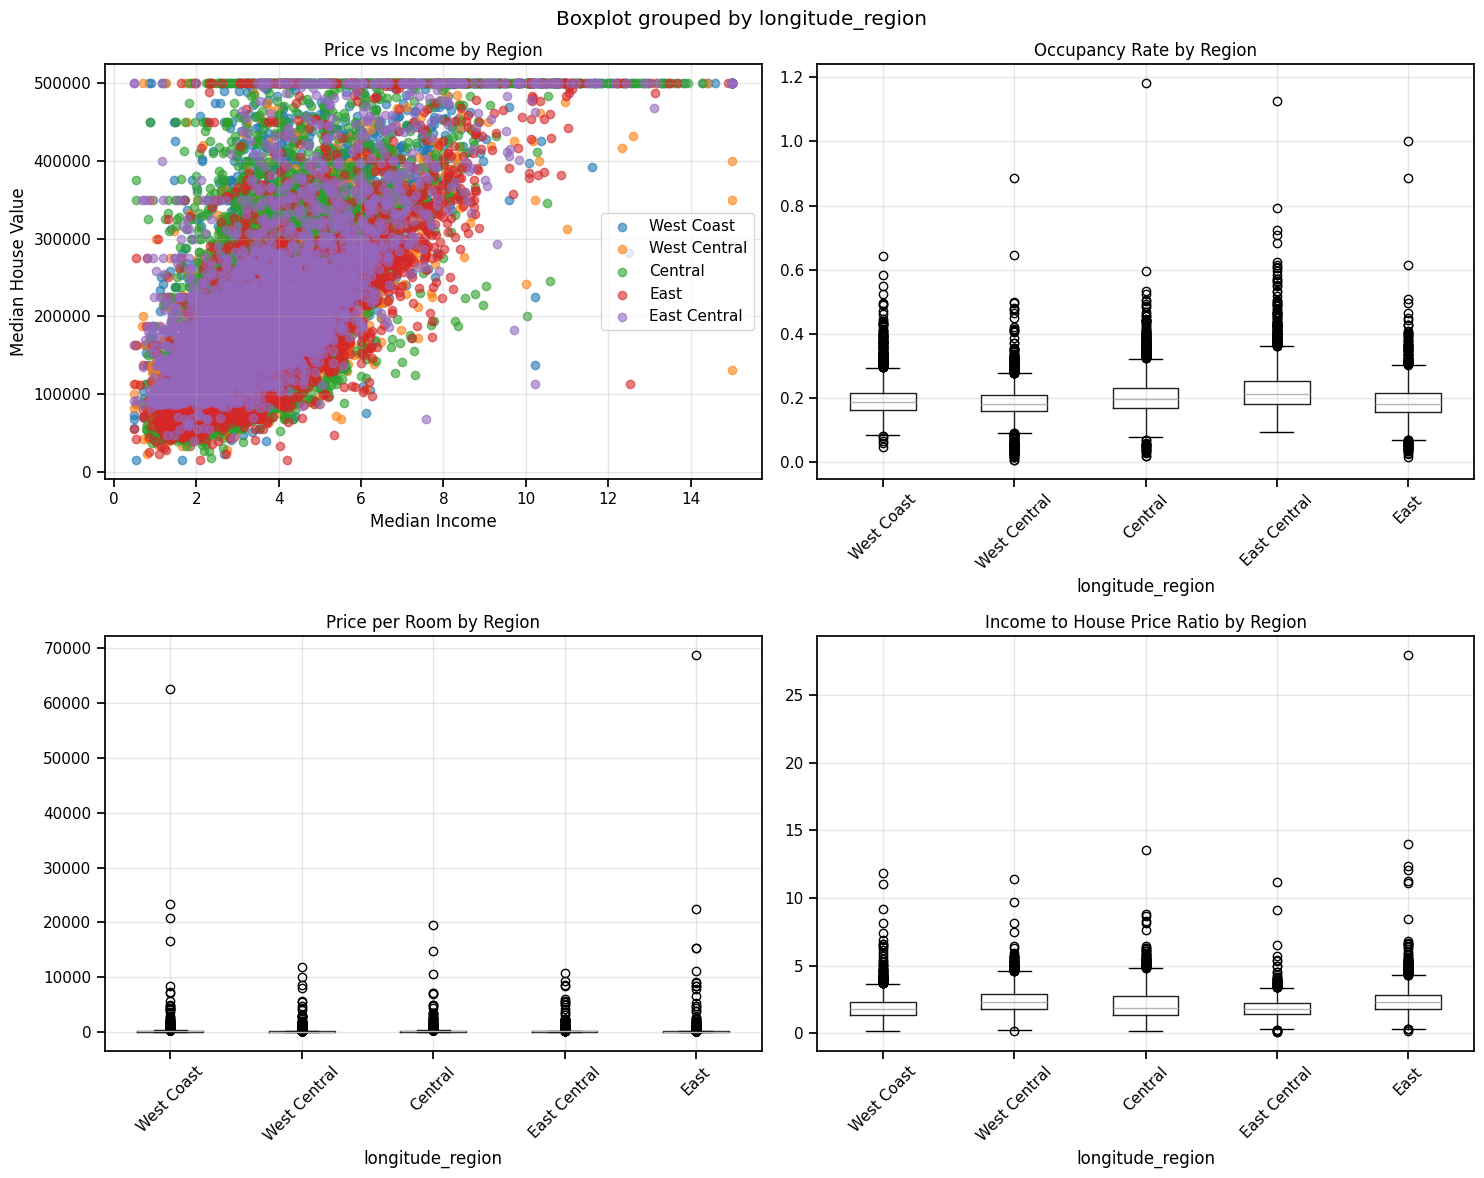

In [6]:
# 2. Local Market Factor Analysis

# Calculate local market indicators
df['price_per_room'] = df['median_house_value'] / df['total_rooms']
df['occupancy_rate'] = df['households'] / df['total_rooms']
df['income_to_house_ratio'] = df['median_income'] / (df['median_house_value'] / 100000)

# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Local Market Analysis', fontsize=14, y=1.02)

# Price vs Income by Region
for region in df['longitude_region'].unique():
    region_data = df[df['longitude_region'] == region]
    axes[0,0].scatter(region_data['median_income'], 
                      region_data['median_house_value'],
                      alpha=0.6,
                      label=region)
axes[0,0].set_title('Price vs Income by Region')
axes[0,0].set_xlabel('Median Income')
axes[0,0].set_ylabel('Median House Value')
axes[0,0].legend()

# Occupancy Rate Distribution
df.boxplot(column='occupancy_rate', by='longitude_region', ax=axes[0,1])
axes[0,1].set_title('Occupancy Rate by Region')
axes[0,1].tick_params(axis='x', rotation=45)

# Price per Room Distribution
df.boxplot(column='price_per_room', by='longitude_region', ax=axes[1,0])
axes[1,0].set_title('Price per Room by Region')
axes[1,0].tick_params(axis='x', rotation=45)

# Income to House Price Ratio
df.boxplot(column='income_to_house_ratio', by='longitude_region', ax=axes[1,1])
axes[1,1].set_title('Income to House Price Ratio by Region')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

[Rest of the notebook sections remain the same...]